In [ ]:
from run_inference import *

def load_models(name="best", expt_id=None, device="cpu"):
    if expt_id is None:
        expt_id = experiment_id

    if name not in ["best", "last", "latest"]:
        raise NotImplementedError("Only `best`, `last`, and `latest` models are supported")
    
    if name=="best":
        suffix = ""
    else:
        suffix = f"_{name}"
    
    print(f"Loading `{name}` model")

    model = torch.load(f"models/{expt_id}/model{suffix}.pt", map_location=device, weights_only=False)
    scoremodel = torch.load(f"models/{expt_id}/scmodel{suffix}.pt", map_location=device, weights_only=False)
    embed_model = torch.load(f"models/{expt_id}/embed_model{suffix}.pt", map_location=device, weights_only=False)
    if os.path.exists(f"models/{expt_id}/preembed_model{suffix}.pt"):
        preembed_model = torch.load(f"models/{expt_id}/preembed_model{suffix}.pt", map_location=device, weights_only=False)
    else:
        tokenize_transform = lambda x: tokenize(x, args)[0]
        preembed_model = TransformInput(tokenize_transform).to(device)
    
    if os.path.exists(f"models/{expt_id}/aggregator{suffix}.pt"):
        aggregator = torch.load(f"models/{expt_id}/aggregator{suffix}.pt", map_location=device, weights_only=False)
    else:
        aggregator = None

    return model, scoremodel, embed_model, preembed_model, aggregator

In [ ]:
args = argparse.Namespace(expt_id="A01091914", dataset="audio", device=0)

experiment_id = args.expt_id
expt_root = f"models/{experiment_id}/"
dataset = args.dataset
args.device = 1
DEVICE = f"cuda:{args.device}" if torch.cuda.is_available() and args.device != -1 else "cpu"

import pickle
with open(os.path.join(expt_root, "args.pkl"), "rb") as file:
    args = pickle.load(file)

model, scoremodel, embed_model, preembed_model, aggregator = load_models(name="best", expt_id=experiment_id, device=DEVICE)
model.eval(), scoremodel.eval(), embed_model.eval(), preembed_model.eval()
if aggregator is not None:
    aggregator.eval()

nwt, lamwt = next(scoremodel.parameters()).exp().detach().cpu()
nwt, lamwt = nwt.item(), lamwt.item()

print(f"normscore weight: {nwt:.4f}, lamscore weight: {lamwt:.4f}")

DATA_ROOT = f"final_data/{dataset}"
TEST_FILE = f"{DATA_ROOT}/dataset_test.hdf5"

image_embed_model = None
if "cifar" in dataset:
    image_embed_model_ckpt = "data/image_sequence/embedding_models/cifar_ae.pkl"
    image_embed_model = Autoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

    image_embed_model = image_embed_model.to(DEVICE)
    TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

if "lsun" in dataset:
    image_embed_model_ckpt = "data/image_sequence/embedding_models/lsun_ae.pkl"
    image_embed_model = LSUNAutoencoder()
    image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
    image_embed_model.eval()

    for param in image_embed_model.parameters():
        param.requires_grad = False

    image_embed_model = image_embed_model.to(DEVICE)
    TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

test_dataset = PairDatasetTest(TEST_FILE)
print(f"test subset of dataset: \"{dataset}\" loaded from {TEST_FILE}")

##### HPARAMS ######
b = args.b          # hinge margin for negative gap penalty (b-Apa)
b1 = args.b1         # hinge margin for positive gap penalty (Apa-b)
delta = args.delta     # hinge margin for contrastive loss
lr = args.lr
nepochs = args.nepochs
stagger = args.stagger
lamwt = args.lamwt    # loss coefficient for negative gap penalty
gapwt = args.gapwt       # loss coefficient for positive gap penalty
M = 6
N = 20
####################

A_mat, a_vec, Rm_mat = get_opas_constants(M, N, DEVICE)

CFG = AttributeDict({
    'tau': 1,
    'n_sink_iter': 20,
    'n_samples': 1,
})

Loading `best` model
normscore weight: 3.5466, lamscore weight: 0.3973
test subset of dataset: "audio" loaded from final_data/audio/dataset_test.hdf5


In [ ]:
C = embed_full_corpus(test_dataset, embed_model, preembed_model, image_embed_model=image_embed_model, aggregator=aggregator)

In [ ]:
SEED = 42069

with torch.no_grad():
    torch.manual_seed(SEED)
    loader = test_dataset.get_dataloader(batch_size=10, shuffle=True)
    q, l = next(iter(loader))

    q = q.to(next(model.parameters()).device) 
    # q is bmd, c is Nnd, l is bN
    q = q + batch_get_white_noise(q, args.SNR)     # torch.randn_like(q) * noise
    q = embed_if_image_and_normalize(q, image_embed_model)
    q = embed_model(preembed_model(q))
    q = normalize(q)
    # q is (b, m, xoutdim)
    if aggregator is None:
        qct = torch.einsum("bmd,Nnd->bNmn", q, C)
        model_inputs = stagger_and_concat(qct, num_stagger=stagger) # bNsmn  s = num_stagger+1

        lambdas = torch.stack([model(x) for x in model_inputs])
        # bNm1

        F_mat = Rm_mat.T @ (2*qct + (a_vec @ lambdas.transpose(2,3) @ A_mat).transpose(2,3))

        P = gumbel_sinkhorn(F_mat, CFG.tau, CFG.n_sink_iter, noise=False)

        RmPC = Rm_mat @ P @ C.squeeze(-1)

        lamscore = lamwt * (lambdas.transpose(2,3) @ (b-A_mat @ Rm_mat @ P @ a_vec)).squeeze()
        normscore = torch.norm(q.unsqueeze(1) - RmPC, dim=[-1,-2])

        allscores = torch.stack([lamscore, normscore], dim=2)
        netscore = 2*scoremodel(-allscores).squeeze()      # b
    else:
        q = aggregator(q)
        # q is bd, C is Nd, we want bN scores
        # b1d - 1Nd = bNd --> sum across last dim to get bN scores
        netscore = 2 * F.sigmoid(-F.relu(q.unsqueeze(1) - C.unsqueeze(0)).sum(dim=-1))    # bN

    netscores = netscore.cpu()
    true_labels = l.cpu()

    ranking = netscores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(true_labels, dim=1, index=ranking)

    mRR = (1 / (ranked_output.argmax(dim=1) + 1)).mean().item()

    MAP = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
    MAP /= (torch.arange(ranked_output.shape[1]) + 1)
    MAP /= torch.sum(ranked_output, dim=1, keepdim=True)
    MAP = MAP.sum(dim=1).mean().item()

    print(f"mRR: {mRR:.4f}, mAP: {MAP:.4f}")

mRR: 1.0000, mAP: 1.0000


In [ ]:
torch.manual_seed(SEED)
loader = test_dataset.get_dataloader(batch_size=10, shuffle=True)
q, l = next(iter(loader))

def get_true_mapping(idx):
    query = q[idx].cpu()
    label = l[idx].cpu()
    cpos_locs = label.nonzero().squeeze()
    corpuses = torch.from_numpy(test_dataset.c[cpos_locs])

    mapping = []
    for i in range(len(query)):
        for j in range(len(corpuses[0])):
            dist = torch.norm(query[i] - corpuses[0][j])
            if dist < 1e-8:
                mapping.append(j)
    return mapping, cpos_locs

info = [get_true_mapping(i) for i in range(len(q))]

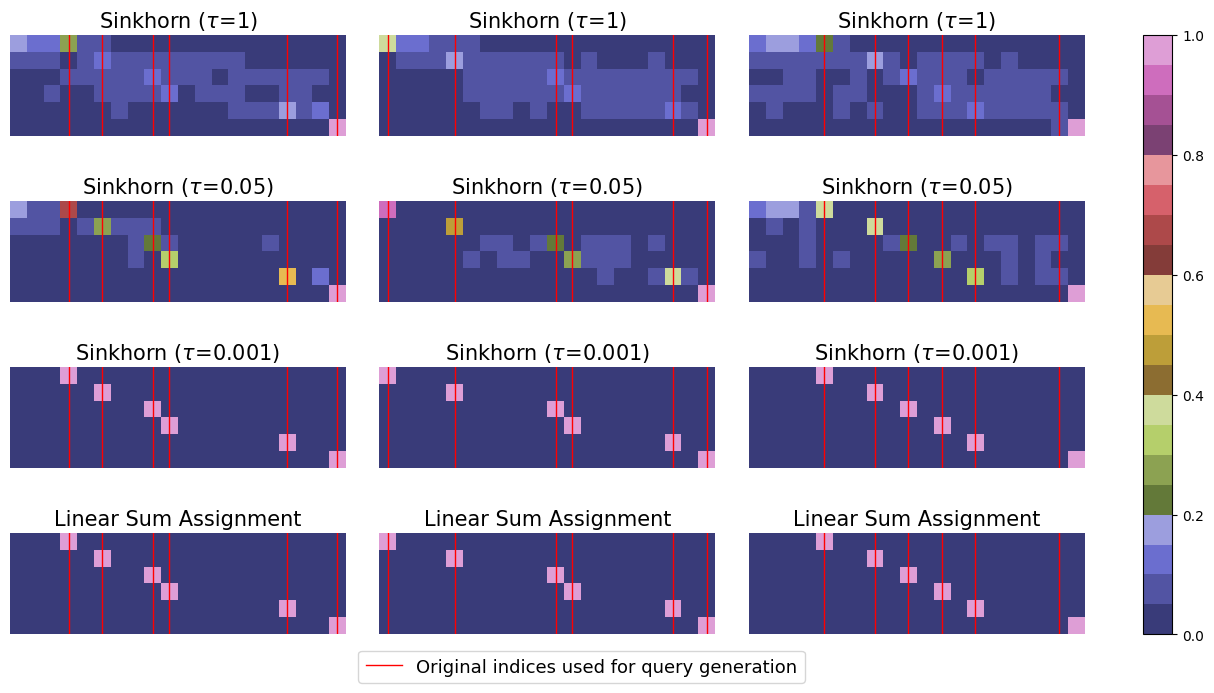

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

from opas.utils import gumbel_matching, gumbel_sinkhorn

axes_off = np.vectorize(lambda ax: ax.axis('off'))

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 15
label_fontsize = 15
cmap = "tab20b"

nsamp = 3
ridx = [0, 3, 7]
# ridx = np.random.choice(range(len(q)), nsamp, replace=False)
plot_f = False
figlen = 5 if plot_f else 4
figheight = 10 if plot_f else 8
fig, ax = plt.subplots(figlen, nsamp, figsize=(5*nsamp, figheight))
fig.subplots_adjust(hspace=0.4, wspace=0.1)
axes_off(ax)

all_perms = []
for i in range(nsamp):
    F_ = F_mat[ridx[i]][info[ridx[i]][1][0]].cpu().detach().unsqueeze(0)
    P_ = P[ridx[i]][info[ridx[i]][1][0]].cpu().detach().unsqueeze(0)
    if plot_f:
        ax[0][i].imshow(F_[0][:6], cmap=cmap)
        ax[0][i].set_title(f"Cost matrix $F$", fontsize=title_fontsize)
    for j, tau in enumerate([1, 0.05, 0.001]):
        if plot_f:
            j += 1
        P__ = gumbel_sinkhorn(P_.clone(), tau, CFG.n_sink_iter, noise=False)[0][:6]
        all_perms.append(P__)
        im = ax[j][i].imshow(P__, cmap=cmap)
        ax[j][i].set_title(fr"Sinkhorn ($\tau$={tau})", fontsize=title_fontsize)
        # plt.colorbar(im, ax=ax[j][i])
    Pm = gumbel_matching(F_, noise=False)[0][:6]
    all_perms.append(Pm)
    im = ax[-1][i].imshow(Pm, cmap=cmap)
    ax[-1][i].set_title("Linear Sum Assignment", fontsize=title_fontsize)
    # plt.colorbar(im, ax=ax[-1][i])


    for j in range(figlen):
        for loc in info[ridx[i]][0]:
            ax[j][i].axvline(loc, color='r', lw=1, label="Original indices used for query generation")
        if j == 0:
            handles, labels = ax[j][i].get_legend_handles_labels()

handles, labels = handles[:1], labels[:1]
fig.colorbar(im, ax=ax, fraction=0.0258)
legend = fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=13)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+0.1), loc=2, ncol=5, fontsize=13)
# fig.savefig(f'plots_and_figures/inference_alignments_{plot_f}.pdf', bbox_inches='tight')
plt.show()